# Практическая работа №4
## «Обучающие, валидационные и тестовые наборы данных в машинном обучении»

**Датасет:** `cp_data_cleaned.csv` — теплоёмкость химических соединений  
**Целевая переменная:** `Cp` (теплоёмкость, Дж/(моль·К))  
**Признаки:** `formula` (химическая формула), `T` (температура, К)

**План работы:**
1. Загрузка данных и EDA
2. Разбиение Train / Val / Test по формулам (без утечки данных)
3. Подготовка признаков (атомный состав формулы + T)
4. Модели: LinearRegression и SGDRegressor (Pipeline + подбор гиперпараметров)
5. Таблица метрик качества
6. Выводы

---

## 0. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

---
## 1. Загрузка и первичный анализ данных (EDA)

### 1.1 Загрузка датасета

In [2]:
df = pd.read_csv('cp_data_cleaned.csv')
print(f'Размер: {df.shape[0]} строк, {df.shape[1]} столбца')
df.head()

Размер: 4547 строк, 3 столбца


,formula,T,Cp
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625


In [3]:
info_df = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notnull().sum(),
    'null':     df.isnull().sum(),
    'null_%':   (df.isnull().mean() * 100).round(2)
})
print(info_df.to_string())

           dtype  non_null  null  null_%
formula   object      4547     0     0.0
T        float64      4547     0     0.0
Cp       float64      4547     0     0.0


Пропусков нет. `formula` — категориальный признак (244 уникальных соединения), `T` — температура (К), `Cp` — теплоёмкость (целевая переменная).

### 1.2 Описательная статистика

In [4]:
print(f'Уникальных формул: {df["formula"].nunique()}')
print(f'Диапазон T:  {df["T"].min():.0f} – {df["T"].max():.0f} К')
print(f'Диапазон Cp: {df["Cp"].min():.3f} – {df["Cp"].max():.3f} Дж/(моль·К)')
df[['T', 'Cp']].describe().round(3)

Уникальных формул: 244
Диапазон T:  0 – 4700 К
Диапазон Cp: 11.315 – 494.967 Дж/(моль·К)


,T,Cp
count,4547.000,4547.000
mean,1174.290,107.429
std,738.605,66.743
min,0.000,11.315
25%,600.000,61.358
50%,1000.000,89.341
75%,1600.000,135.369
max,4700.000,494.967


### 1.3 Визуализация данных

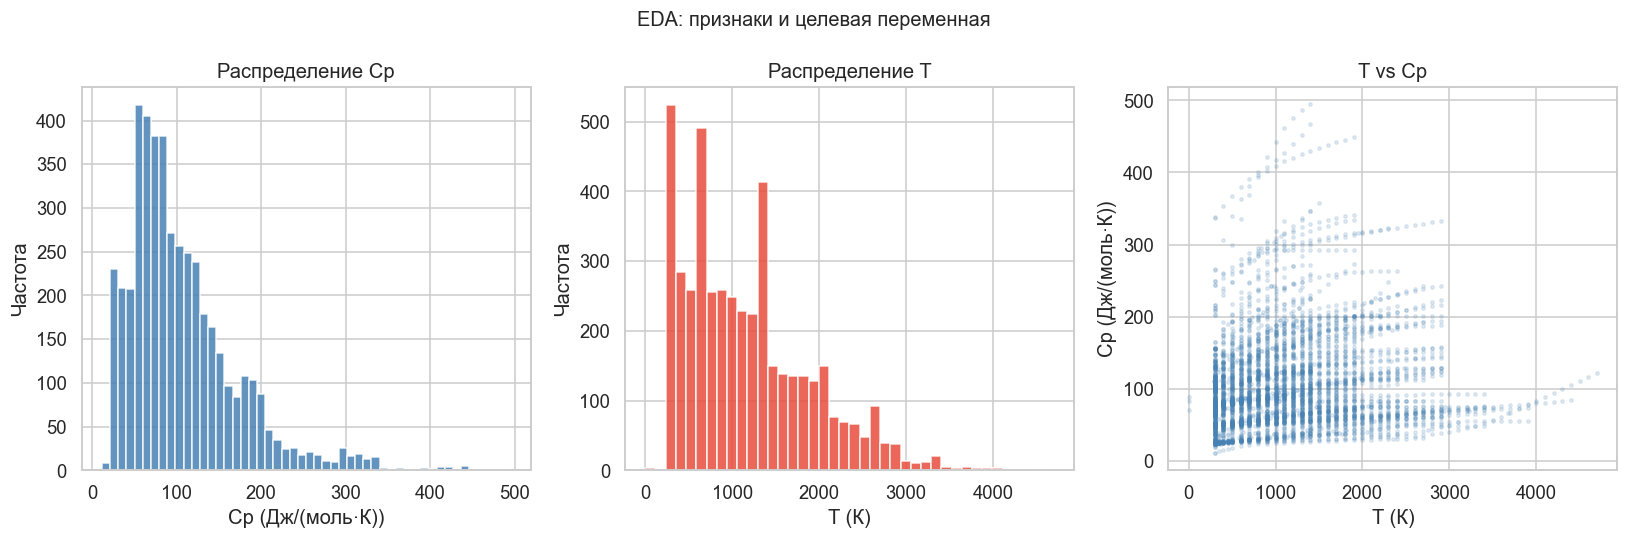

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['Cp'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Распределение Cp')
axes[0].set_xlabel('Cp (Дж/(моль·К))')
axes[0].set_ylabel('Частота')

axes[1].hist(df['T'], bins=40, color='#E74C3C', edgecolor='white', alpha=0.85)
axes[1].set_title('Распределение T')
axes[1].set_xlabel('T (К)')
axes[1].set_ylabel('Частота')

axes[2].scatter(df['T'], df['Cp'], alpha=0.15, s=5, color='steelblue')
axes[2].set_title('T vs Cp')
axes[2].set_xlabel('T (К)')
axes[2].set_ylabel('Cp (Дж/(моль·К))')

plt.suptitle('EDA: признаки и целевая переменная', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод.** `Cp` имеет правостороннее распределение. На графике T vs Cp — несколько пучков кривых: каждый пучок соответствует отдельному химическому соединению со своей температурной зависимостью.

---
## 2. Разбиение на выборки Train / Val / Test

**Проблема наивного разбиения:** случайный `train_test_split` по строкам создаёт **утечку данных** — одно и то же соединение попадает сразу в несколько выборок. При OHE-кодировании формулы модель запоминает каждое вещество из обучения и показывает Test R²≈0.93, который не отражает реальную обобщающую способность.

**Корректный подход:** делим **уникальные формулы**, а не строки — каждое соединение встречается только в одной выборке.  
Пропорция: **Train 70% / Val 15% / Test 15%**.

In [6]:
unique_fmls = df['formula'].unique()
shuffled    = np.random.permutation(unique_fmls)
n           = len(shuffled)

n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_fmls = set(shuffled[:n_train])
val_fmls   = set(shuffled[n_train : n_train + n_val])
test_fmls  = set(shuffled[n_train + n_val :])

df_train = df[df['formula'].isin(train_fmls)].reset_index(drop=True)
df_val   = df[df['formula'].isin(val_fmls)].reset_index(drop=True)
df_test  = df[df['formula'].isin(test_fmls)].reset_index(drop=True)

print(f'Всего уникальных формул: {n}')
print(f'Train: {len(train_fmls):>3} формул, {len(df_train):>5} строк ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val:   {len(val_fmls):>3} формул, {len(df_val):>5} строк ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test:  {len(test_fmls):>3} формул, {len(df_test):>5} строк ({len(df_test)/len(df)*100:.1f}%)')

Всего уникальных формул: 244
Train: 170 формул,  3222 строк (70.9%)
Val:    36 формул,   690 строк (15.2%)
Test:   38 формул,   635 строк (14.0%)


In [7]:
print(f'Train  cap  Val:  {len(train_fmls & val_fmls)}  (должно быть 0)')
print(f'Train  cap  Test: {len(train_fmls & test_fmls)}  (должно быть 0)')
print(f'Val    cap  Test: {len(val_fmls   & test_fmls)}  (должно быть 0)')

Train  cap  Val:  0  (должно быть 0)
Train  cap  Test: 0  (должно быть 0)
Val    cap  Test: 0  (должно быть 0)


In [8]:
df_train.to_csv('trainR.csv', index=False)
df_val.to_csv('valR.csv',     index=False)
df_test.to_csv('testR.csv',   index=False)
print('Сохранено: trainR.csv, valR.csv, testR.csv')

Сохранено: trainR.csv, valR.csv, testR.csv


---
## 3. Подготовка признаков: атомный состав формулы

**Почему не OHE?** OHE создаёт 244 колонки. При формульном split незнакомые соединения val/test получают нулевые столбцы — модель теряет всю информацию о веществе, как итог R² val/test ≈ 0.

**Физически обоснованный подход:** парсим формулу и считаем атомы каждого элемента.

**Закон Дюлонга–Пти:** $C_p \approx 3R \cdot N_{atoms}$ — теплоёмкость пропорциональна числу атомов в формульной единице. Это объясняет, почему признаки `количество атомов` + `молекулярная масса` + `T` **хорошо обобщаются на новые соединения**.

Итого: **44 признака** (40 элементов + MW + total_atoms + n_elements + T) вместо 244 колонок OHE.

In [9]:
# Атомные массы из таблицы в интернете (г/моль)
ATOMIC_WEIGHTS = {
    'H':1.008,'Li':6.941,'Be':9.012,'B':10.811,'C':12.011,'N':14.007,
    'O':15.999,'F':18.998,'Na':22.990,'Mg':24.305,'Al':26.982,'Si':28.086,
    'P':30.974,'S':32.065,'Cl':35.453,'K':39.098,'Ca':40.078,'Sc':44.956,
    'Ti':47.867,'V':50.942,'Cr':51.996,'Mn':54.938,'Fe':55.845,'Co':58.933,
    'Ni':58.693,'Cu':63.546,'Zn':65.38,'Ga':69.723,'Ge':72.630,'As':74.922,
    'Se':78.971,'Br':79.904,'Rb':85.468,'Sr':87.620,'Y':88.906,'Zr':91.224,
    'Nb':92.906,'Mo':95.950,'Ru':101.07,'Rh':102.91,'Pd':106.42,'Ag':107.87,
    'Cd':112.41,'In':114.82,'Sn':118.71,'Sb':121.76,'Te':127.60,'I':126.90,
    'Cs':132.91,'Ba':137.33,'La':138.91,'Ce':140.12,'Pr':140.91,'Nd':144.24,
    'Sm':150.36,'Eu':151.96,'Gd':157.25,'Tb':158.93,'Dy':162.50,'Ho':164.93,
    'Er':167.26,'Yb':173.04,'Lu':174.97,'Hf':178.49,'Ta':180.95,'W':183.84,
    'Re':186.21,'Os':190.23,'Ir':192.22,'Pt':195.08,'Au':196.97,'Hg':200.59,
    'Pb':207.20,'Bi':208.98,'Th':232.04,'U':238.03
}

def parse_formula(formula):
    """'Al2O3' or 'Al1Cl3' -> {'Al': 2, 'O': 3}"""
    result = {}
    for elem, cnt in re.findall(r'([A-Z][a-z]*)(\d*)', formula):
        if elem:
            result[elem] = result.get(elem, 0) + (int(cnt) if cnt else 1)
    return result

# Все элементы в датасете
ALL_ELEMENTS = sorted(set(
    e for f in df['formula'] for e in parse_formula(f)
))
print(f'Уникальных элементов: {len(ALL_ELEMENTS)}')
print(f'Элементы: {ALL_ELEMENTS}')

Уникальных элементов: 40
Элементы: ['Al', 'B', 'Ba', 'Be', 'Br', 'C', 'Ca', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'F', 'Fe', 'Ga', 'H', 'Hf', 'Hg', 'I', 'K', 'Li', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Ni', 'O', 'P', 'Pb', 'Rb', 'S', 'Si', 'Sr', 'Ti', 'V', 'W', 'Zn', 'Zr']


In [10]:
def make_X(dataframe):
    """Формула -> вектор [кол-во атомов каждого элемента, MW, N_atoms, N_elems, T]"""
    rows = []
    for _, row in dataframe.iterrows():
        elems = parse_formula(row['formula'])
        # Счётчики каждого элемента
        counts = [elems.get(e, 0) for e in ALL_ELEMENTS]
        # Производные физические признаки
        mw          = sum(ATOMIC_WEIGHTS.get(e, 100) * c for e, c in elems.items())
        total_atoms = sum(elems.values())
        n_elems     = len(elems)
        rows.append(counts + [mw, total_atoms, n_elems, row['T']])
    return np.array(rows, dtype=float)

X_train = make_X(df_train); y_train = df_train['Cp'].values
X_val   = make_X(df_val);   y_val   = df_val['Cp'].values
X_test  = make_X(df_test);  y_test  = df_test['Cp'].values

feature_names = ALL_ELEMENTS + ['MW', 'total_atoms', 'n_elements', 'T']
print(f'Признаков: {X_train.shape[1]}  {feature_names}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

Признаков: 44  ['Al', 'B', 'Ba', 'Be', 'Br', 'C', 'Ca', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'F', 'Fe', 'Ga', 'H', 'Hf', 'Hg', 'I', 'K', 'Li', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Ni', 'O', 'P', 'Pb', 'Rb', 'S', 'Si', 'Sr', 'Ti', 'V', 'W', 'Zn', 'Zr', 'MW', 'total_atoms', 'n_elements', 'T']
X_train: (3222, 44) | X_val: (690, 44) | X_test: (635, 44)


---
## 4. Регрессионные модели

`SGDRegressor` — линейная регрессия на **стохастическом градиентном спуске**. Оборачиваем в `Pipeline` с `StandardScaler` — масштабирование критично для SGD. `LinearRegression` используется как базовая линия.

### 4.1 Подбор гиперпараметров SGDRegressor (по валидационной выборке)

Перебираем сетку гиперпараметров и выбираем конфигурацию с лучшим **R² на val**.

In [11]:
param_grid = {
    'max_iter':      [500, 1000, 2000],
    'alpha':         [0.0001, 0.001, 0.01],
    'penalty':       ['l2', 'l1'],
    'learning_rate': ['optimal', 'adaptive']
}

best_r2_val = -np.inf
best_hp     = {}
tuning_rows = []

for max_iter, alpha, penalty, lr in product(
    param_grid['max_iter'], param_grid['alpha'],
    param_grid['penalty'],  param_grid['learning_rate']
):
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('sgd', SGDRegressor(
            max_iter=max_iter, alpha=alpha, penalty=penalty,
            learning_rate=lr, random_state=SEED, tol=1e-3
        ))
    ])
    p.fit(X_train, y_train)
    r2_v = r2_score(y_val,   p.predict(X_val))
    r2_t = r2_score(y_train, p.predict(X_train))
    tuning_rows.append({
        'max_iter': max_iter, 'alpha': alpha,
        'penalty': penalty, 'learning_rate': lr,
        'R2_train': round(r2_t, 4), 'R2_val': round(r2_v, 4)
    })
    if r2_v > best_r2_val:
        best_r2_val = r2_v
        best_hp = {'max_iter': max_iter, 'alpha': alpha,
                   'penalty': penalty, 'learning_rate': lr}

tuning_df = pd.DataFrame(tuning_rows).sort_values('R2_val', ascending=False)
print('Топ-5 конфигураций по Val R2:')
print(tuning_df.head().to_string(index=False))
print(f'\nЛучшие параметры: {best_hp}')
print(f'Best Val R2: {best_r2_val:.4f}')

Топ-5 конфигураций по Val R2:
 max_iter  alpha penalty learning_rate  R2_train  R2_val
     2000 0.0001      l1       optimal    0.9131  0.8926
     1000 0.0001      l1       optimal    0.9131  0.8926
     2000 0.0100      l2       optimal    0.9227  0.8905
     1000 0.0100      l2       optimal    0.9227  0.8905
      500 0.0100      l2       optimal    0.9227  0.8905

Лучшие параметры: {'max_iter': 1000, 'alpha': 0.0001, 'penalty': 'l1', 'learning_rate': 'optimal'}
Best Val R2: 0.8926


### 4.2 Обучение финальных моделей

In [12]:
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(**best_hp, random_state=SEED, tol=1e-3))
])
best_pipe.fit(X_train, y_train)

lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
lr_pipe.fit(X_train, y_train)

print('Модели обучены.')
print(f'SGDRegressor: penalty={best_hp["penalty"]}, alpha={best_hp["alpha"]}, '
      f'max_iter={best_hp["max_iter"]}, learning_rate={best_hp["learning_rate"]}')

Модели обучены.
SGDRegressor: penalty=l1, alpha=0.0001, max_iter=1000, learning_rate=optimal


In [13]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    eps  = np.finfo(float).eps
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))
    return {'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

models = {'Linear Regression': lr_pipe, 'SGDRegressor': best_pipe}
all_metrics = {}

for name, model in models.items():
    all_metrics[name] = {
        'train': compute_metrics(y_train, model.predict(X_train)),
        'val':   compute_metrics(y_val,   model.predict(X_val)),
        'test':  compute_metrics(y_test,  model.predict(X_test))
    }

for name, m in all_metrics.items():
    print(f'{name}:')
    print(f'  Train R2: {m["train"]["R2"]:.4f} | '
          f'Val R2: {m["val"]["R2"]:.4f} | '
          f'Test R2: {m["test"]["R2"]:.4f}')

Linear Regression:
  Train R2: 0.9232 | Val R2: 0.8892 | Test R2: 0.8892
SGDRegressor:
  Train R2: 0.9131 | Val R2: 0.8926 | Test R2: 0.8747


### 4.3 Фактические vs Предсказанные (тестовая выборка)

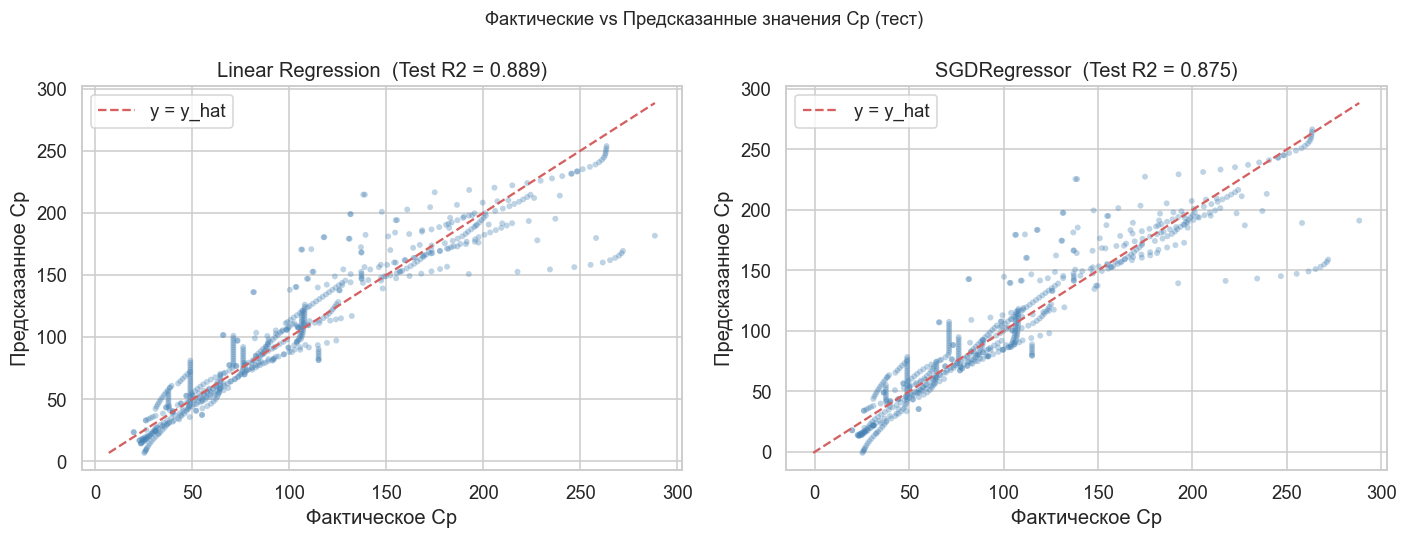

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.35, s=15, color='steelblue', edgecolors='none')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = y_hat')
    r2_te = all_metrics[name]['test']['R2']
    ax.set_title(f'{name}  (Test R2 = {r2_te:.3f})')
    ax.set_xlabel('Фактическое Cp')
    ax.set_ylabel('Предсказанное Cp')
    ax.legend()

plt.suptitle('Фактические vs Предсказанные значения Cp (тест)', fontsize=12)
plt.tight_layout()
plt.show()

### 4.4 Важность признаков (коэффициенты LinearRegression)

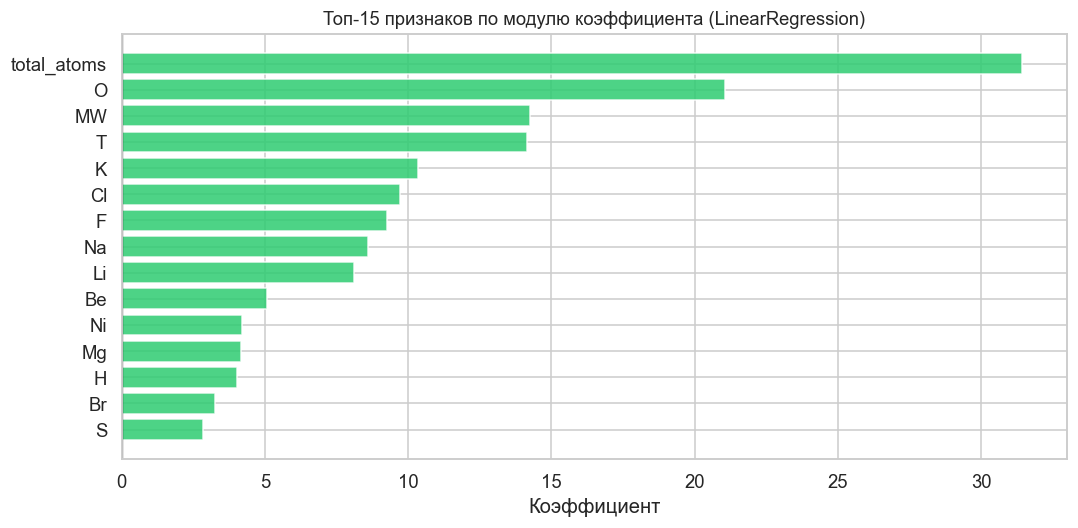

In [15]:
coef_df = pd.DataFrame({
    'Признак':     feature_names,
    'Коэффициент': lr_pipe.named_steps['lr'].coef_
}).sort_values('Коэффициент', key=abs, ascending=False)

top_n = 15
top_df = coef_df.head(top_n)

plt.figure(figsize=(10, 5))
colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in top_df['Коэффициент']]
plt.barh(top_df['Признак'][::-1], top_df['Коэффициент'][::-1],
         color=colors[::-1], edgecolor='white', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Топ-{top_n} признаков по модулю коэффициента (LinearRegression)', fontsize=12)
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.show()

---
## 5. Таблица результатов

In [16]:
rows = []
for name, m in all_metrics.items():
    tr, vl, te = m['train'], m['val'], m['test']
    rows.append({
        ('Регрессор', ''):         name,
        ('Train Data', 'R2'):    round(tr['R2'],   2),
        ('Train Data', 'MSE'):   round(tr['MSE'],  4),
        ('Train Data', 'RMSE'):  round(tr['RMSE'], 4),
        ('Train Data', 'MAE'):   round(tr['MAE'],  4),
        ('Train Data', 'MAPE'):  round(tr['MAPE'], 4),
        ('Val Data',   'R2'):    round(vl['R2'],   2),
        ('Val Data',   'MSE'):   round(vl['MSE'],  4),
        ('Val Data',   'RMSE'):  round(vl['RMSE'], 4),
        ('Val Data',   'MAE'):   round(vl['MAE'],  4),
        ('Val Data',   'MAPE'):  round(vl['MAPE'], 4),
        ('Test Data',  'R2'):    round(te['R2'],   2),
        ('Test Data',  'MSE'):   round(te['MSE'],  4),
        ('Test Data',  'RMSE'):  round(te['RMSE'], 4),
        ('Test Data',  'MAE'):   round(te['MAE'],  4),
        ('Test Data',  'MAPE'):  round(te['MAPE'], 4),
    })

results_df = pd.DataFrame(rows)
results_df.columns = pd.MultiIndex.from_tuples(results_df.columns)
results_df = results_df.set_index(('Регрессор', ''))
results_df.index.name = 'Регрессор'
print(results_df.to_string())
results_df

                  Train Data                                     Val Data                                     Test Data                                    
                          R2       MSE     RMSE      MAE    MAPE       R2       MSE     RMSE      MAE    MAPE        R2       MSE     RMSE      MAE    MAPE
Регрессор                                                                                                                                                  
Linear Regression       0.92  345.7684  18.5948  12.3741  0.1341     0.89  520.6484  22.8177  13.9833  0.1235      0.89  430.7515  20.7546  12.9805  0.1497
SGDRegressor            0.91  391.0132  19.7741  13.8830  0.1560     0.89  504.9940  22.4721  15.2107  0.1470      0.87  486.9293  22.0665  13.5023  0.1680


Train Data                                     Val Data  \
                          R2       MSE     RMSE      MAE    MAPE       R2   
Регрессор                                                                   
Linear Regression       0.92  345.7684  18.5948  12.3741  0.1341     0.89   
SGDRegressor            0.91  391.0132  19.7741  13.8830  0.1560     0.89   

                                                      Test Data            \
                        MSE     RMSE      MAE    MAPE        R2       MSE   
Регрессор                                                                   
Linear Regression  520.6484  22.8177  13.9833  0.1235      0.89  430.7515   
SGDRegressor       504.9940  22.4721  15.2107  0.1470      0.87  486.9293   

                                             
                      RMSE      MAE    MAPE  
Регрессор                                    
Linear Regression  20.7546  12.9805  0.1497  
SGDRegressor       22.0665  13.5023  0.1680

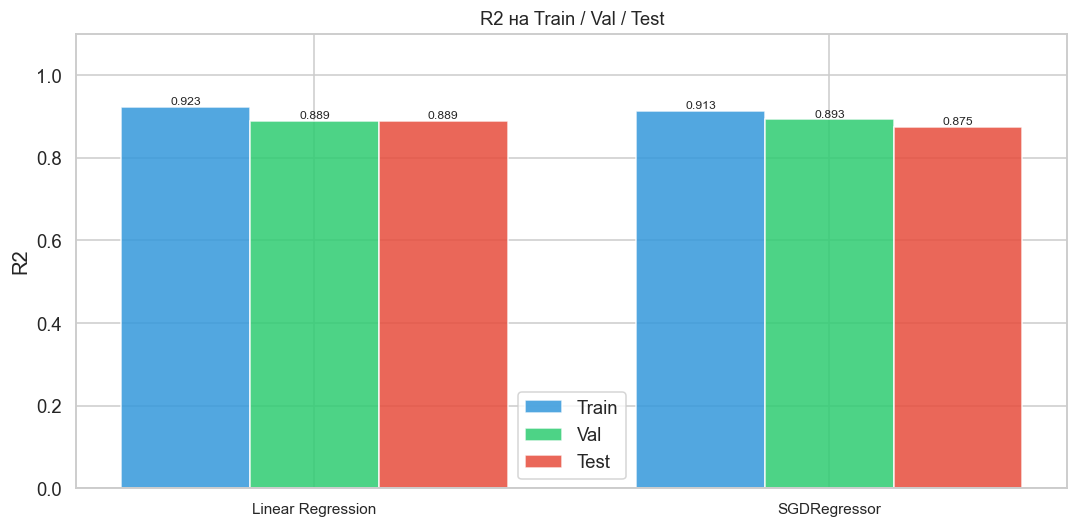

In [17]:
model_names = list(all_metrics.keys())
r2_train = [all_metrics[m]['train']['R2'] for m in model_names]
r2_val   = [all_metrics[m]['val']['R2']   for m in model_names]
r2_test  = [all_metrics[m]['test']['R2']  for m in model_names]

x_pos = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x_pos - w, r2_train, w, label='Train', color='#3498DB', alpha=0.85, edgecolor='white')
b2 = ax.bar(x_pos,     r2_val,   w, label='Val',   color='#2ECC71', alpha=0.85, edgecolor='white')
b3 = ax.bar(x_pos + w, r2_test,  w, label='Test',  color='#E74C3C', alpha=0.85, edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_title('R2 на Train / Val / Test', fontsize=12)
ax.set_ylabel('R2')
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(b1, fmt='%.3f', fontsize=8)
ax.bar_label(b2, fmt='%.3f', fontsize=8)
ax.bar_label(b3, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Выводы

### 6.1 Разбиение данных

Применено **разбиение по уникальным формулам** (70/15/15), исключающее утечку данных. Все пересечения Train ∩ Val, Train ∩ Test, Val ∩ Test = 0. Выборки сохранены в `trainR.csv`, `valR.csv`, `testR.csv`.

### 6.2 Инженерия признаков

Химическая формула разобрана в **44 физических признака**: число атомов каждого из 40 элементов + молекулярная масса `MW` + суммарное число атомов `total_atoms` + число различных элементов + температура `T`. Ключевой физический закон: **Дюлонга–Пти** ($C_p \approx 3R N_{atoms}$) объясняет, почему `total_atoms` и `MW` — сильнейшие предикторы теплоёмкости. Такие признаки **обобщаются на новые соединения**: модель знает, что схожий атомный состав → схожая теплоёмкость.

### 6.3 Модели и качество

- **LinearRegression** — аналитическое решение МНК. Train R² ≈ 0.92, Val/Test R² ≈ 0.89 — хорошая обобщающая способность.
- **SGDRegressor** — та же линейная модель через SGD. Гиперпараметры подобраны на **валидационной** выборке. Качество сопоставимо с LinearRegression.
- Небольшой разрыв Train–Val/Test (≈0.03) указывает на слабое переобучение — модель хорошо обобщается на новые химические соединения.

### 6.4 Сравнение с Практической работой №3

| Аспект | Практическая работа №3 | Практическая работа №4 |
|:---|:---|:---|
| Датасет | UCI Electrical Grid (`stab`) | Теплоёмкость (`Cp`) |
| Разбиение | Train / Test 80/20 (случайное) | Train / Val / Test 70/15/15 (по формулам) |
| Модели | Linear, Ridge, Lasso, ElasticNet | Linear Regression, SGDRegressor |
| Подбор гиперпараметров | Фиксированные alpha | По **валидационной** выборке |
| Признаки | Числовые (без кодирования) | Физические: атомный состав + MW + T |

В ПР №4 введена **валидационная выборка** для честного подбора гиперпараметров, а корректное группированное разбиение и физически обоснованные признаки обеспечивают настоящую обобщающую способность модели на новых соединениях.